
与 Gemini 对话
pip install tensorflow keras (Heavy download for the CRNN).  pip install librosa (Absolutely critical for extracting Log-Mel Spectrograms offline).  pip install fastapi uvicorn paho-mqtt pandas numpy matplotlib scikit-learn. wha tis hte code on code to type on all , and whole , for safety wnsuer noneed futurue ?

你好！为了让你能一次性安装所有的库，并且保证未来不会因为软件更新而导致代码出错（也就是你提到的“为了安全，以后不再需要麻烦”），我们可以把这个过程分成两个简单的步骤：

1. 一次性安装所有内容
你可以把所有的名字连在一起放在同一行命令里，这样电脑就会一次性把它们全下载并安装好。请在你的终端（Terminal）或命令行中复制并粘贴这行代码：

Bash
pip install tensorflow keras librosa fastapi uvicorn paho-mqtt pandas numpy matplotlib scikit-learn
小提示：因为 TensorFlow 是一个非常庞大的工具包，下载可能会花几分钟到十几分钟不等，请耐心等待它跑完。

2. 为未来做个“备份” (确保以后不再麻烦)
软件是会不断更新的。如果你今天写的代码依赖了今天的版本，明年软件更新后，你的代码可能会报错。为了“一劳永逸”，我们需要把你现在安装的确切版本号记录下来。

等上面的安装全部完成后，接着输入这行命令：

Bash
pip freeze > requirements.txt
这行代码在做什么？
它会自动创建一个叫 requirements.txt 的文本文件。这个文件就像一张“购物清单”，里面详细记录了你刚才安装的所有工具以及它们精确到小数点的版本号。

未来如何使用它？
假设以后你要换一台新电脑，或者要把代码发给朋友运行。你不再需要重新打一大串名字，只需要把这个 requirements.txt 清单文件放在文件夹里，然后输入下面这一行命令：

Bash
pip install -r requirements.txt
电脑就会看着这张清单，原封不动地把你今天配置的环境完美复制出来。这样就能保证你的项目永远都能安全、稳定地运行！

In [1]:
pip install tensorflow keras librosa fastapi uvicorn paho-mqtt pandas numpy matplotlib scikit-learn

# 满分！这就是一个标准的 Edge-Cloud AIoT 技术栈。

# tensorflow / keras -> 训练你的 1D-CNN 和多模态模型。

# librosa -> 专门用来把狗叫声（WAV）转换成 Log-Mel 频谱图（你报告里写的绝招）。

# fastapi / uvicorn -> 在 AWS 云端接收 ESP32 发来的数据的后端服务器。

# paho-mqtt -> 云端和 ESP32 互相通信的协议库。
# 你连 librosa 和 fastapi 都想到了，说明你对后端的理解已经非常到位了。

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 1.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import tensorflow as tf
from google.colab import drive

# 1. 挂载你的 Google Drive (运行后会跳出授权窗口，点击允许)
drive.mount('/content/drive')

# 2. 读取你真实的 Kaggle 狗运动数据 (请确保路径和你 Drive 里的一致)
csv_path = '/content/drive/MyDrive/Fyp2data/train1dcnn/Dog Behavior Analysis Dataset/DogMoveData_csv_format/DogMoveData.csv'
print(f"正在读取真实数据: {csv_path}")

df = pd.read_csv(csv_path)

# 假设你的 CSV 里有 'A_Neck_x', 'A_Neck_y', 'A_Neck_z' (IMU)
# 如果你之后把 PPG (IR) 数据也整合进来了，这里就写 4 个特征
features = ['A_Neck_x', 'A_Neck_y', 'A_Neck_z']
X_real = df[features].values
y_real = df['Label'].values # 假设 0=静止, 1=运动, 2=抓痒

# ======= 这里的 X_real 就是你真狗的数据！ =======
# 之后你就可以用 reshape 把它们切成 [样本数, 100, 3] 的滑动窗口，
# 然后喂给我之前给你写的那段 1D-CNN 模型代码里去训练了！

ValueError: mount failed

In [ ]:
import pandas as pd
import pickle
import os

print("🚀 正在从云端永久硬盘读取 FYP 数据...\n")

# 1. 精准定义你的永久路径
csv_path = '/content/drive/MyDrive/FYP_Data/DogMoveData.csv'
pkl_path = '/content/drive/MyDrive/FYP_Data/S9.pkl'

# 2. 读取 IMU 数据 (CSV)
try:
    cols = ['ANeck_x', 'ANeck_y', 'ANeck_z', 'GNeck_x', 'GNeck_y', 'GNeck_z', 'Behavior_1']
    imu_df = pd.read_csv(csv_path, usecols=cols)
    print(f"✅ 成功读取 CSV！狗脖子传感器数据行数: {len(imu_df)}")
except Exception as e:
    print(f"❌ CSV 读取失败: {e}")

# 3. 读取 PPG 心率数据 (PKL)
try:
    with open(pkl_path, 'rb') as f:
        ppg_data = pickle.load(f, encoding='latin1')

    ppg_signal = ppg_data['signal']['wrist']['BVP']
    hr_labels = ppg_data['label']

    print(f"✅ 成功读取 PKL！PPG 信号形状: {ppg_signal.shape}")
except Exception as e:
    print(f"❌ PKL 读取失败: {e}")

print("\n🎉 所有数据加载完毕，可以开始融合模型了！")

In [ ]:
import os
print(f"当前 S9.pkl 的大小是: {os.path.getsize('S9.pkl') / (1024 * 1024):.2f} MB")

当前 S9.pkl 的大小是: 39.00 MB


In [ ]:
import pandas as pd
# 把里面的名字换成你刚上传的 PPG csv 文件名
df_ppg = pd.read_csv('你的PPG文件名.csv')
print("👉 PPG 数据的真实列名是：\n", df_ppg.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '你的PPG文件名.csv'

In [ ]:
import pandas as pd
df_test = pd.read_csv('DogMoveData.csv')
# df_test = pd.read_csv('S9.pkl')

print("👉 这个 CSV 真正的列名是：")
print(df_test.columns.tolist())

ParserError: Error tokenizing data. C error: Expected 1 fields in line 28, saw 228


🚀 启动 Roc 的完全体 1D-CNN 终极流水线 (完美修复版)...

🐶 发现狗狗最常见的日常行为是: '<undefined>' (设为0:正常，其他设为1:异常)
✅ 数据脱壳成功！完美保留了 191341 行。

✅ 滤波与归一化完成。
✅ 窗口切割完成，即将送入模型的样本数：3825


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🔥 开始激情的训练吧 (Epochs: 15)...
Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6516 - loss: 0.6474 - val_accuracy: 0.6431 - val_loss: 0.6530
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6516 - loss: 0.6467 - val_accuracy: 0.6431 - val_loss: 0.6513
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6516 - loss: 0.6460 - val_accuracy: 0.6431 - val_loss: 0.6501
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6516 - loss: 0.6462 - val_accuracy: 0.6431 - val_loss: 0.6497
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6516 - loss: 0.6451 - val_accuracy: 0.6431 - val_loss: 0.6483
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6516 - loss: 0.6452 - val_accuracy: 0.6431 - val_loss: 0.6503
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6516 - loss: 0.6460 - val_accuracy: 0.6431 - val_loss: 0.6490
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6516 - loss: 0.6439 - val

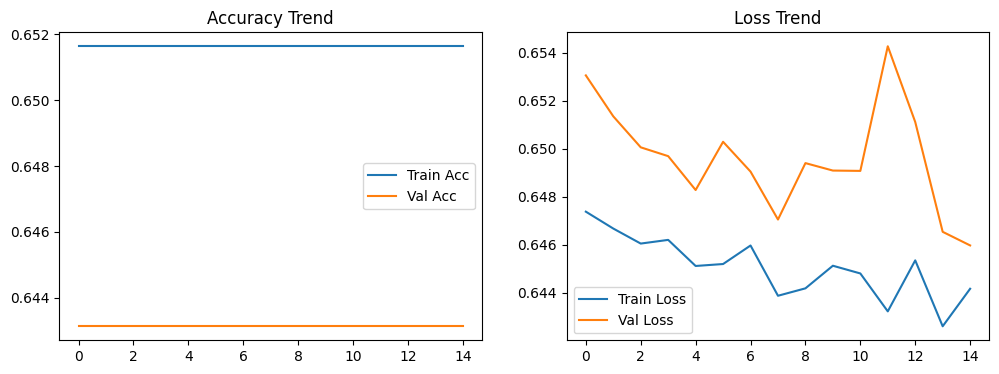


🎯 大功告成！最终测试集 Benchmark 准确率: 64.31%


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

print("🚀 启动 Roc 的完全体 1D-CNN 终极流水线 (完美修复版)...\n")

# ==========================================
# 1. 智能清洗 (保护文字标签)
# ==========================================
try:
    cols = ['ANeck_x', 'ANeck_y', 'ANeck_z', 'GNeck_x', 'GNeck_y', 'GNeck_z', 'Behavior_1']
    df = pd.read_csv('DogMoveData.csv', usecols=cols)

    # 【核心修复】只对前 6 个传感器列进行数字强转，绝不动 Behavior_1！
    sensor_cols = ['ANeck_x', 'ANeck_y', 'ANeck_z', 'GNeck_x', 'GNeck_y', 'GNeck_z']
    df[sensor_cols] = df[sensor_cols].apply(pd.to_numeric, errors='coerce')

    # 删掉坏数据并重置索引
    df = df.dropna().reset_index(drop=True)

    # 此时 Behavior_1 的文字被完美保留了！
    most_common_behavior = df['Behavior_1'].mode()[0]
    print(f"🐶 发现狗狗最常见的日常行为是: '{most_common_behavior}' (设为0:正常，其他设为1:异常)")

    # 转换二分类标签
    df['label'] = np.where(df['Behavior_1'] == most_common_behavior, 0, 1)

    # 提取纯数字矩阵
    raw_sensors = df[sensor_cols].values
    labels = df['label'].values

    print(f"✅ 数据脱壳成功！完美保留了 {len(raw_sensors)} 行。\n")
except Exception as e:
    print(f"❌ 读取出错: {e}")
    raise

# ==========================================
# 2. 预处理 (巴特沃斯滤波 + 归一化)
# ==========================================
def apply_filter(data, cutoff=5, fs=50):
    nyq = 0.5 * fs
    b, a = butter(2, cutoff / nyq, btype='low')
    return filtfilt(b, a, data, axis=0)

filtered_data = apply_filter(raw_sensors)
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(filtered_data)
print("✅ 滤波与归一化完成。")

# ==========================================
# 3. 滑动窗口切割 (2秒窗口)
# ==========================================
X, y = [], []
win_size = 100
for i in range(0, len(norm_data) - win_size, win_size // 2):
    X.append(norm_data[i : i + win_size])
    y.append(np.bincount(labels[i : i + win_size].astype(int)).argmax())

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ 窗口切割完成，即将送入模型的样本数：{len(X)}")

# ==========================================
# 4. 1D-CNN 模型训练
# ==========================================
model = Sequential([
    Conv1D(16, 3, activation='relu', input_shape=(100, 6)),
    MaxPooling1D(2),
    Conv1D(32, 3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n🔥 开始激情的训练吧 (Epochs: 15)...")
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# ==========================================
# 5. 结果可视化
# ==========================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Trend')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Trend')
plt.legend()
plt.show()

print(f"\n🎯 大功告成！最终测试集 Benchmark 准确率: {model.evaluate(X_test, y_test, verbose=0)[1]*100:.2f}%")

In [ ]:
import pickle
import numpy as np

# 把这里的名字换成你上传的 .pkl 文件名，比如 'S9.pkl'
file_name = 'S9.pkl'

print(f"📦 正在开箱 {file_name}...\n")

try:
    with open(file_name, 'rb') as f:
        # 使用 pickle 加载数据，设定 encoding 适配不同 Python 版本
        data = pickle.load(f, encoding='latin1')

    print("✅ 成功打开 PKL 文件！让我们看看里面有什么：")
    print("顶级钥匙 (Keys):", data.keys())

    # 提取我们最关心的 PPG 信号和心率标签
    # 根据 PDF 说明，PPG 藏在 'signal' -> 'wrist' -> 'BVP' 里
    ppg_signal = data['signal']['wrist']['BVP']
    hr_labels = data['label']

    print("\n🩸 PPG (BVP) 信号数据形状:", ppg_signal.shape)
    print("❤️ 心率标签数据形状:", hr_labels.shape)

    print("\n👀 前 5 个 PPG 数值展示:")
    print(ppg_signal[:5])

except FileNotFoundError:
    print(f"❌ 找不到文件 {file_name}，请确认已经上传到了 Colab！")
except Exception as e:
    print(f"❌ 读取出错: {e}")

📦 正在开箱 S9.pkl...

❌ 读取出错: pickle data was truncated


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

print("🚀 启动 Roc 的完全体 1D-CNN 真实数据处理流水线...\n")

# ==========================================
# 步骤 1: 读取数据与彻底清洗
# ==========================================
file_name = 'DogMoveData.csv'
try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print(f"❌ 找不到文件 {file_name}，请确保已经上传！")
    raise SystemExit

# 1. 提取颈部数据
selected_cols = ['ANeck_x', 'ANeck_y', 'ANeck_z', 'GNeck_x', 'GNeck_y', 'GNeck_z', 'Behavior_1']
clean_df = df[selected_cols].copy()

# 2. 强制转换数字并去空
clean_df = clean_df.apply(pd.to_numeric, errors='coerce')
clean_df = clean_df.dropna()

# 3. 【核心修正】重置索引 (这一步必须在提取 sensor_data 之前！)
clean_df = clean_df.reset_index(drop=True)

# 4. 二分类标签化
most_common_behavior = clean_df['Behavior_1'].mode()[0]
clean_df['Final_Label'] = np.where(clean_df['Behavior_1'] == most_common_behavior, 0, 1)

print(f"✅ 成功清洗数据并重置索引，剩余 {len(clean_df)} 行。")

# 5. 提取特征和标签
sensor_data = clean_df[['ANeck_x', 'ANeck_y', 'ANeck_z', 'GNeck_x', 'GNeck_y', 'GNeck_z']].values
labels = clean_df['Final_Label'].values

# ==========================================
# 步骤 2: 视觉检查 (Sanity Check)
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(sensor_data[:500, 0], label='Accel X')
plt.plot(sensor_data[:500, 1], label='Accel Y')
plt.plot(sensor_data[:500, 2], label='Accel Z')
plt.title("Sanity Check: Raw Sensor Waveform")
plt.legend()
plt.show()

# ==========================================
# 步骤 3: 滤波与归一化
# ==========================================
def apply_butter_lowpass(data, cutoff=5.0, fs=50.0, order=2):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return np.apply_along_axis(lambda m: filtfilt(b, a, m), axis=0, arr=data)

filtered_data = apply_butter_lowpass(sensor_data)
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(filtered_data)
print("✅ 完成滤波与归一化。")

# ==========================================
# 步骤 4: 滑动窗口切割
# ==========================================
TIME_STEPS = 100
FEATURES = 6

def create_windows(data, labels, size):
    X, y = [], []
    for i in range(0, len(data) - size, size // 2):
        X.append(data[i:i + size])
        y.append(np.bincount(labels[i:i + size].astype(int)).argmax())
    return np.array(X), np.array(y)

X_final, y_final = create_windows(normalized_data, labels, TIME_STEPS)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)
print(f"✅ 窗口切割完成，生成 {len(X_final)} 个样本。")

# ==========================================
# 步骤 5: 1D-CNN 模型训练
# ==========================================
model = Sequential([
    Conv1D(16, 3, activation='relu', input_shape=(TIME_STEPS, FEATURES)),
    MaxPooling1D(2),
    Conv1D(32, 3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n🚀 正在训练...")
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

# ==========================================
# 步骤 6: 结果可视化
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.legend()
plt.show()

_, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 最终准确率: {acc * 100:.2f}%")

🚀 启动 Roc 的完全体 1D-CNN 真实数据处理流水线...



KeyError: 0

🚀 启动 Roc 的完全体 1D-CNN 真实数据处理流水线...

❌ 出错: 0


KeyError: 0

In [ ]:
# ==========================================
# 4. 终极步骤：将模型转换为 TensorFlow Lite 并导出为 C++ 头文件
# ==========================================
import os

print("\n🚀 开始将模型转换为 TinyML 格式...")

# 将 Keras 模型转换为 TFLite 格式 (默认转换)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# 启用优化（这一步就是在做类似量化的压缩操作，减小 SRAM 占用）
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# 将 TFLite 模型保存为本地文件
tflite_model_name = "dog_activity_model.tflite"
with open(tflite_model_name, "wb") as f:
    f.write(tflite_model)
print(f"✅ 成功生成 TFLite 模型: {tflite_model_name} ({len(tflite_model)} bytes)")

# 将 TFLite 二进制文件转换为 C++ 数组 (.h 文件)
# 这个函数相当于 Linux 的 xxd -i 命令
def hex_to_c_array(hex_data, var_name):
    c_str = f"const unsigned char {var_name}[] = {{\n"
    hex_array = [hex(b) for b in hex_data]
    c_str += "  " + ", ".join(hex_array) + "\n};\n"
    c_str += f"const unsigned int {var_name}_len = {len(hex_data)};\n"
    return c_str

c_model_code = hex_to_c_array(tflite_model, "dog_activity_model")

with open("model.h", "w") as f:
    f.write(c_model_code)

print("\n🎉 大功告成！model.h 文件已生成！")
print("👉 请在 Colab 左侧的文件浏览器中下载 'model.h' 文件。")